# 03 · Welch power spectral density 
Compute a PSD from one inspected 60-s LFP segment, inspect its waveform and spectrum,
then apply the same settings to the small example manifest. This follows the Welch
stage of the original `aperiodicparameters_knee.ipynb`.

**Input:** selected preprocessed MAT segments (`data1`, `fs`). **Output:** linear PSD
MAT files, a manifest and a QC figure in `_example_outputs/03_welch`.
No additional filtering, spectral interpolation or amplitude normalization is applied.
The supplied twelve segments are a teaching subset, not complete study phase means.


## 1. Imports and editable settings 


In [1]:
from pathlib import Path
import os, csv
import numpy as np
from scipy.io import loadmat, savemat
import matplotlib.pyplot as plt

# Open Jupyter in this code folder, or set the environment path explicitly.
code_dir = Path(os.environ.get('GATE_OFFLINE_CODE_DIR', '.')).resolve()
assert (code_dir/'example_inputs/lfp_examples.csv').is_file(), 'Open this notebook from its own code folder.'
output_root = Path(os.environ.get('GATE_EXAMPLE_OUTPUT_DIR', code_dir/'_example_outputs'))
plt.rcParams.update({'font.size': 11, 'axes.spines.top': False, 'axes.spines.right': False})

from scipy.signal import welch
out_dir = output_root/'03_welch'
out_dir.mkdir(parents=True, exist_ok=True)
input_mode = 'supplied_examples'   # or 'accepted_step02' for your inspected segment
window_seconds = 2.0
overlap_fraction = 0.5
frequency_range = (2.0, 90.0)


## 2. Select inputs
The default manifest contains two rats × three phases × two segments, selected by
waveform QC only. Rat identity, phase and strategy remain explicit in every output.
To use step 02, change `input_mode`; only a manually accepted segment is permitted.


In [2]:
if input_mode == 'supplied_examples':
    with (code_dir/'example_inputs/lfp_examples.csv').open(encoding='utf-8') as handle:
        examples = list(csv.DictReader(handle))
    input_paths = {r['ExampleID']: code_dir/'example_inputs'/r['File'] for r in examples}
elif input_mode == 'accepted_step02':
    accepted_path = output_root/'02_segments/accepted_segment.mat'
    assert accepted_path.is_file(), 'Inspect and accept a segment in step 02 first.'
    accepted = loadmat(accepted_path, squeeze_me=True)
    assert bool(accepted['qcAccepted']), 'Manual QC acceptance is required.'
    # Edit these three metadata fields to describe your own recording.
    examples = [dict(ExampleID='user_segment', RatID='UserRat', Strategy='UserStrategy',
                     Phase='Pre', File=accepted_path.name)]
    input_paths = {'user_segment': accepted_path}
else:
    raise ValueError('Unknown input_mode')
assert examples and len({r['ExampleID'] for r in examples}) == len(examples)
print(f'{len(examples)} segments selected; no whole-dataset scan is performed.')


12 segments selected; no whole-dataset scan is performed.


## 3. Calculate Welch PSD 
Read the actual sampling rate, use a **periodic Hann** window, remove the mean of
each Welch window, and average periodograms. With 300 Hz sampling, 2-s windows
contain 600 samples, overlap by 300 samples and produce a 0.5-Hz frequency grid.
Keep PSDs linear for FOOOF. Convert to dB only for plotting.


In [3]:
spectra = []
for row in examples:
    data = loadmat(input_paths[row['ExampleID']], squeeze_me=True)
    x = np.asarray(data['data1'], dtype=float).reshape(-1)
    fs = float(data['fs'])
    assert np.isfinite(x).all() and fs > 2*frequency_range[1]
    assert np.isclose(x.size/fs, 60), 'This example expects 60-s segments.'
    n_window = int(round(window_seconds*fs))
    n_overlap = int(round(overlap_fraction*n_window))
    # Construct the window explicitly: no dependency on implicit defaults.
    window = 0.5 - 0.5*np.cos(2*np.pi*np.arange(n_window)/n_window)
    frequency, psd = welch(x, fs=fs, window=window, nperseg=n_window,
                           noverlap=n_overlap, nfft=n_window, detrend='constant',
                           scaling='density', return_onesided=True, average='mean')
    keep = (frequency >= frequency_range[0]) & (frequency <= frequency_range[1])
    frequency, psd = frequency[keep], psd[keep]
    assert (psd > 0).all() and np.isfinite(psd).all()
    savemat(out_dir/(row['ExampleID']+'_psd.mat'), {
        'freq': frequency, 'psd_linear': psd, 'fs': fs,
        'window_seconds': window_seconds, 'overlap_fraction': overlap_fraction,
        'example_id': row['ExampleID']})
    spectra.append(dict(row=row, frequency=frequency, psd=psd, x=x, fs=fs))
with (out_dir/'processed_manifest.csv').open('w', newline='', encoding='utf-8') as handle:
    writer = csv.DictWriter(handle, fieldnames=examples[0].keys())
    writer.writeheader(); writer.writerows(examples)
print('Saved linear Welch spectra and metadata.')


Saved linear Welch spectra and metadata.


## 4. Inspect a representative segment
The first supplied input is a Pre segment. All waveform samples and PSD bins are
shown; axes are limited only to the stated analysis frequency range. Input amplitude
units are retained because calibration is not encoded in these MAT files.


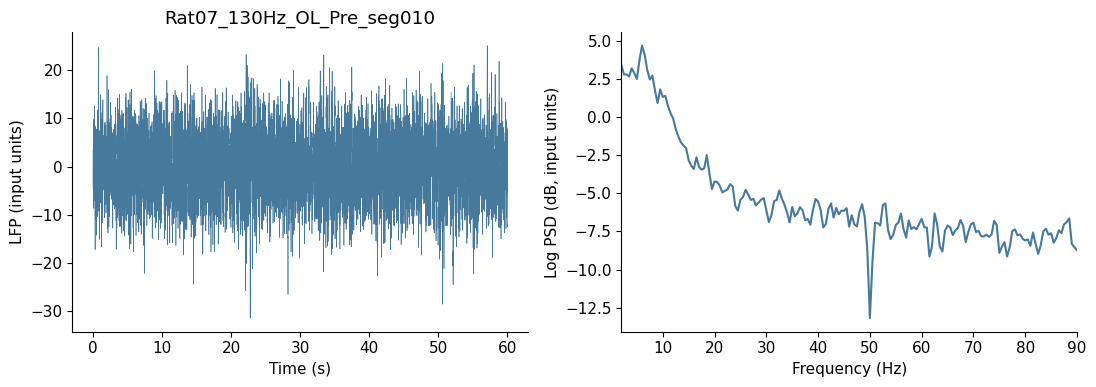

In [4]:
example = spectra[0]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(np.arange(example['x'].size)/example['fs'], example['x'], lw=0.45, color='#46799c')
axes[0].set(xlabel='Time (s)', ylabel='LFP (input units)', title=example['row']['ExampleID'])
axes[1].plot(example['frequency'], 10*np.log10(example['psd']), color='#46799c')
axes[1].set(xlabel='Frequency (Hz)', ylabel='Log PSD (dB, input units)', xlim=frequency_range)
fig.tight_layout()
fig.savefig(out_dir/'welch_QC.png', dpi=180)
plt.show()


## 5. Next step
Run **04_spectral_parameterization.ipynb**. Its input is the **linear** `psd_linear`
array, not the plotted dB values. The saved `freq` vector determines all band masks.
